# Lab 07 — NLP Evaluation: Airline Tweet Sentiment

**Worked Python solution.** This notebook uses the single supplied `Tweets.csv` file to build a reproducible three-class sentiment benchmark. It uses a majority-class baseline and a Multinomial Naive Bayes model with training-only vocabulary fitting.

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=FutureWarning)

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "all_datasets").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the course project.")
ROOT=find_project_root()
print("Project root:",ROOT)

import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score, confusion_matrix, ConfusionMatrixDisplay

RESULTS=ROOT/"results"/"lab07"; RESULTS.mkdir(parents=True,exist_ok=True)
raw=pd.read_csv(ROOT/"all_datasets"/"lab07-Tweets.csv")
work=raw[["tweet_id","text","airline_sentiment","airline"]].dropna(subset=["text","airline_sentiment","airline"]).copy()
print("Raw rows:",len(raw),"| missing usable text:",raw.text.isna().sum(),"| duplicate text:",work.text.duplicated().sum())
print(work.airline_sentiment.value_counts())
work=work.drop_duplicates("text",keep="first").reset_index(drop=True)

Project root: /mnt/data/ai_course_final/ARTIFICIAL INTELLIGENCE


Raw rows: 14640 | missing usable text: 0 | duplicate text: 213
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


## 1. Fixed stratified 70/15/15 split

In [2]:
idx=np.arange(len(work)); train_idx,temp_idx=train_test_split(idx,test_size=.30,random_state=42,stratify=work.airline_sentiment); val_idx,test_idx=train_test_split(temp_idx,test_size=.50,random_state=42,stratify=work.airline_sentiment.iloc[temp_idx])
split=np.full(len(work),"train",object); split[val_idx]="validation"; split[test_idx]="test"
pd.DataFrame({"tweet_id":work.tweet_id,"split":split}).to_csv(RESULTS/"split.csv",index=False)
print(pd.Series(split).value_counts())

train         10098
test           2165
validation     2164
Name: count, dtype: int64


## 2. Training-only text features and validation choice

In [3]:
url_re=re.compile(r"https?://\S+|www\.\S+"); mention_re=re.compile(r"@\w+")
def clean_text(text):
    text=url_re.sub(" URL ",text); text=mention_re.sub(" USER ",text)
    return text.lower()

validation=[]
for ngram in [(1,1),(1,2)]:
    for alpha in [.3,.5,1.0,2.0]:
        vec=CountVectorizer(preprocessor=clean_text,stop_words="english",min_df=2,max_features=20000,ngram_range=ngram)
        Xtr=vec.fit_transform(work.text.iloc[train_idx]); Xv=vec.transform(work.text.iloc[val_idx])
        model=MultinomialNB(alpha=alpha).fit(Xtr,work.airline_sentiment.iloc[train_idx])
        validation.append({"ngram":str(ngram),"alpha":alpha,"validation_macro_f1":f1_score(work.airline_sentiment.iloc[val_idx],model.predict(Xv),average="macro")})
validation=pd.DataFrame(validation).sort_values("validation_macro_f1",ascending=False); display(validation.round(4))
best=validation.iloc[0]; print("Selected:",best.ngram,"alpha=",best.alpha)

,ngram,alpha,validation_macro_f1
5,"(1, 2)",0.5,0.6980
6,"(1, 2)",1.0,0.6939
4,"(1, 2)",0.3,0.6936
1,"(1, 1)",0.5,0.6902
0,"(1, 1)",0.3,0.6901
2,"(1, 1)",1.0,0.6828
3,"(1, 1)",2.0,0.6576
7,"(1, 2)",2.0,0.6542


Selected: (1, 2) alpha= 0.5


In [4]:
selected_ngram=(1,2) if "2" in best.ngram else (1,1)
vectorizer=CountVectorizer(preprocessor=clean_text,stop_words="english",min_df=2,max_features=20000,ngram_range=selected_ngram)
Xtrain=vectorizer.fit_transform(work.text.iloc[train_idx]); Xtest=vectorizer.transform(work.text.iloc[test_idx])
model=MultinomialNB(alpha=float(best.alpha)).fit(Xtrain,work.airline_sentiment.iloc[train_idx])
ytest=work.airline_sentiment.iloc[test_idx].to_numpy(); pred=model.predict(Xtest); majority=work.airline_sentiment.iloc[train_idx].mode()[0]; base_pred=np.repeat(majority,len(test_idx))

def metric_row(name,p):
    pr,rc,f,_=precision_recall_fscore_support(ytest,p,average="macro",zero_division=0)
    return {"model":name,"accuracy":accuracy_score(ytest,p),"macro_precision":pr,"macro_recall":rc,"macro_f1":f}
metrics=pd.DataFrame([metric_row("Majority baseline",base_pred),metric_row("Multinomial NB",pred)])
metrics.to_csv(RESULTS/"metrics.csv",index=False); display(metrics.round(4))

,model,accuracy,macro_precision,macro_recall,macro_f1
0,Majority baseline,0.6296,0.2099,0.3333,0.2576
1,Multinomial NB,0.7612,0.6985,0.6826,0.6882


## 3. Confusion matrix and airline-level performance

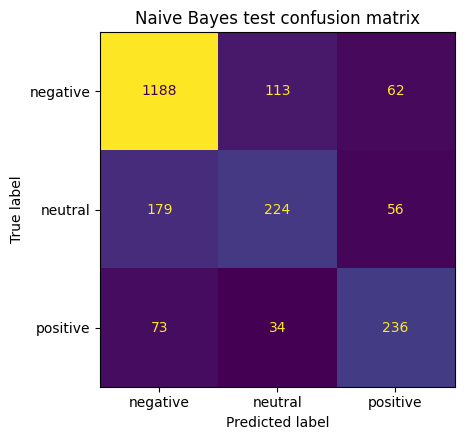

,airline,n_test,macro_f1
3,US Airways,407,0.641
2,Southwest,384,0.650
4,United,578,0.650
5,Virgin America,67,0.656
0,American,388,0.711
1,Delta,341,0.738


In [5]:
classes=["negative","neutral","positive"]
fig,ax=plt.subplots(figsize=(5.5,4.5)); ConfusionMatrixDisplay(confusion_matrix(ytest,pred,labels=classes),display_labels=classes).plot(ax=ax,colorbar=False); ax.set_title("Naive Bayes test confusion matrix"); fig.tight_layout(); fig.savefig(RESULTS/"confusion_matrix.png",dpi=160); plt.show()

test=work.iloc[test_idx].copy(); test["prediction"]=pred
rows=[]
for airline,g in test.groupby("airline"):
    rows.append({"airline":airline,"n_test":len(g),"macro_f1":f1_score(g.airline_sentiment,g.prediction,average="macro",zero_division=0)})
by_airline=pd.DataFrame(rows).sort_values("macro_f1"); by_airline.to_csv(RESULTS/"per_airline_f1.csv",index=False); display(by_airline.round(3))

## 4. Structured error analysis

In [6]:
err=test[test.airline_sentiment!=test.prediction][["tweet_id","airline","airline_sentiment","prediction","text"]].head(12).copy()
# These categories are a manual reading of this fixed, deterministic 12-row sample.
categories=["neutral ambiguity","negation / context","context missing","context missing","sarcasm / irony","context missing","unusual vocabulary","context missing","neutral ambiguity","negation","context missing","context missing"]
err["error_category"]=categories
err.to_csv(RESULTS/"error_analysis.csv",index=False); display(err)

,tweet_id,airline,airline_sentiment,prediction,text,error_category
1223,569877449389051906,United,neutral,negative,@united at the gate! IAD to RDU,neutral ambiguity
4054,567838896731615234,United,neutral,negative,"@united no, I had to leave for work. Would hav...",negation / context
14300,569605022197153792,American,positive,negative,@AmericanAir my return flight is scheduled on ...,context missing
6731,570293669628157952,Delta,neutral,negative,@JetBlue Ok and in Dominican Republic what num...,context missing
5931,568458879220076545,Southwest,positive,negative,"@SouthwestAir is really stepping up their ""ser...",sarcasm / irony
8865,567759774016868352,Delta,neutral,negative,"@JetBlue Well, I try! See you soon!! @JayVig",context missing
4235,567748863449395201,United,positive,negative,@United WiFi onboard 737-800 far superior in p...,unusual vocabulary
5303,569194554290774016,Southwest,positive,neutral,@SouthwestAir is the best. Case and point. htt...,context missing
9766,569656884262793216,US Airways,neutral,negative,@USAirways Cancelled Flightled the last part o...,neutral ambiguity
5549,568888623787089920,Southwest,negative,neutral,@SouthwestAir no one I call knows anything abo...,negation


In [7]:
best_airline=by_airline.iloc[-1]; worst_airline=by_airline.iloc[0]
print(f"Best airline subset: {best_airline.airline} (macro F1={best_airline.macro_f1:.3f})")
print(f"Worst airline subset: {worst_airline.airline} (macro F1={worst_airline.macro_f1:.3f})")
print("Most common reviewed error categories:")
print(err.error_category.value_counts())

Best airline subset: Delta (macro F1=0.738)
Worst airline subset: US Airways (macro F1=0.641)
Most common reviewed error categories:
error_category
context missing       6
neutral ambiguity     2
negation / context    1
sarcasm / irony       1
unusual vocabulary    1
negation              1
Name: count, dtype: int64


## Worked interpretation

Naive Bayes substantially exceeds the majority baseline, especially on macro F1, which matters because the class distribution is imbalanced. The confusion matrix shows that **neutral** tweets are particularly difficult: factual questions and short context-dependent messages often contain vocabulary that also appears in complaints. Positive tweets can also be misclassified when gratitude appears alongside problem-related terms.

Per-airline scores should not be interpreted as airline quality. They reflect different sample sizes, topics, vocabulary, and class mixtures in the test subset. The correct conclusion is about **model transfer across subgroups**, not about business performance.